In [2]:
import chartout

In [3]:
import pandas as pd
import numpy as np
import altair as alt


# Create timeseries data
rng = np.random.default_rng(905)
ex_ts = pd.DataFrame(
    rng.random((10, 4)),
    columns=['a', 'b', 'c', 'd'],
).assign(
    date=pd.date_range(
        start=pd.to_datetime('2022-02-22')-pd.Timedelta(9, unit='D'),
        end=pd.to_datetime('2022-02-22')).strftime('%Y-%m-%d'),
)

# Create heatmap with selection
select_x = alt.selection_point(fields=['level_0'], name='select_x', value='b')
select_y = alt.selection_point(fields=['level_1'], name='select_y', value='d')
heatmap = alt.Chart(
    ex_ts.drop(columns='date').corr().stack().reset_index().rename(columns={0: 'correlation'}),
    title='Click a tile to compare timeseries',
    height=250,
    width=250,
).mark_rect().encode(
    alt.X('level_0').title(None),
    alt.Y('level_1').title(None),
    alt.Color('correlation').scale(domain=[-1, 1], scheme='blueorange'),
    opacity=alt.when(select_x, select_y).then(alt.value(1)).otherwise(alt.value(0.4)),
).add_params(
    select_x, select_y
)

# Create chart with individual lines/timeseries
base = alt.Chart(
    ex_ts.melt(
        id_vars='date',
        var_name='category',
        value_name='value',
    ),
    height=100,
    width=300,
    title='Individual timeseries',
)
lines = base.transform_filter(
    # If the category is not in the selected values, the returned index is -1
    'indexof(datum.category, select_x.level_0) !== -1'
   '| indexof(datum.category, select_y.level_1) !== -1'
).mark_line().encode(
    alt.X('date:T').axis(labels=False).title(None),
    alt.Y('value').scale(domain=(0, 1)),
    alt.Color('category').legend(orient='top', offset=-20).title(None)
)

# Create chart with difference between lines/timeseries
dynamic_title = alt.Title(alt.expr(f'"Difference " + {select_x.name}.level_0 + " - " + {select_y.name}.level_1'))
# We pivot transform to get each category as a column
lines_diff = base.transform_pivot(
    'category', 'value', groupby=['date']
# In the calculate transform we use the values from the selection to subset the columns to substract
).transform_calculate(
    difference = f'datum[{select_x.name}.level_0] - datum[{select_y.name}.level_1]'
).mark_line(color='grey').encode(
    alt.X('date:T').axis(format='%Y-%m-%d').title(None),
    alt.Y('difference:Q').scale(domain=(-1, 1)),
).properties(
    title=dynamic_title
)

# Layout the charts
chart = (lines & lines_diff) | heatmap
chart
# products = chartout.customizables(debug=True)
# products[0]['textures'][0]['content'] = chart
# products

alt.HConcatChart(...)

In [4]:
store = chartout.Store(chart)
store

Store(active_item={'id': 'my_canvas_id', 'name': 'Canvas', 'textures': [{'id': 'my_canvas_texture', 'content':…

In [5]:
store.active_item

{'name': 'Mug',
 'id': 'my_mug_id',
 'textures': [{'id': 'my_mug_texture',
   'user_modifications': {'dx': 0,
    'dy': 0,
    'scale': 1,
    'alignment': {'horizontal': 'center', 'vertical': 'middle'}},
   'content': <memory at 0x13fdb7dc0>}],
 'quantity': 1}

In [7]:
type(store.init_viz)

dict

In [8]:
store.cart

[{'name': 'Canvas',
  'id': 'my_canvas_id',
  'textures': [{'id': 'my_canvas_texture',
    'user_modifications': {'dx': 0,
     'dy': 0,
     'scale': 1,
     'alignment': {'horizontal': 'center', 'vertical': 'top'}},
    'content': <memory at 0x106a70280>}],
  'quantity': 1},
 {'name': 'Mug',
  'id': 'my_mug_id',
  'textures': [{'id': 'my_mug_texture',
    'user_modifications': {'dx': 0,
     'dy': 0,
     'scale': 1.3000000000000003,
     'alignment': {'horizontal': 'left', 'vertical': 'middle'}},
    'content': <memory at 0x106a70400>}],
  'quantity': 1}]

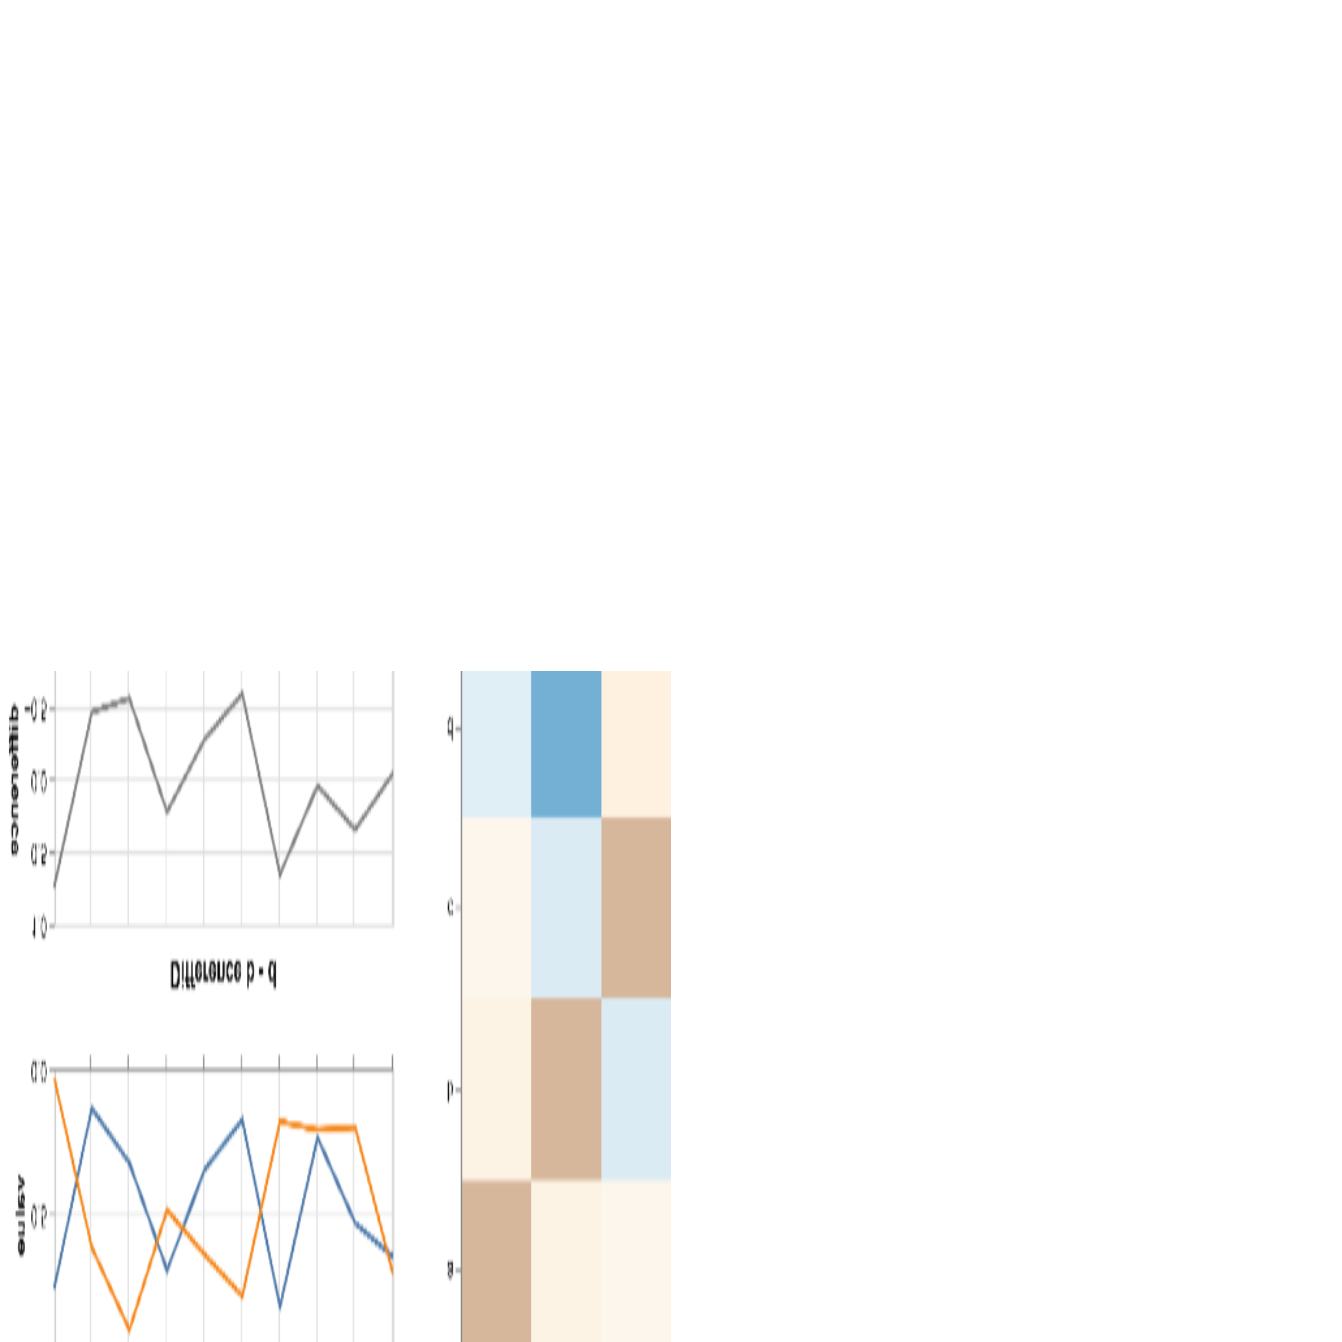

In [9]:
from IPython.display import Image as IPythonImage
texture_data = store.active_texture['texture']
IPythonImage(texture_data, width=300)

In [6]:
cart = chartout.Cart()

In [7]:
cart.add(chart)

TypeError: isinstance() arg 2 must be a type, a tuple of types, or a union

In [9]:
chartout.CartItem(id='1', name='2', textures=[], quantity=1)

CartItem(id='1', name='2', textures=[], quantity=1)

In [ ]:
{
    'id': 'my_mousepad_id', 
    'textures': [{
        'id': 'my_mousepad_texture', 
        'content': chart
        }]
}

In [ ]:
store.active_item

In [ ]:
store.cart

In [ ]:
# cart = store.cart
# cart.append(cart[0])

In [ ]:
active_item = chartout.viz_to_active_item(chart)

In [ ]:
active_item.to_dict()

In [ ]:
active_texture = chartout.viz_to_texture(chart, active_item.to_dict())
active_texture.to_dict()

In [ ]:
item = {"name":"foo", "code": "bah", "image":variant_texture, "quantity":1}
cart = chartout.Cart()
cart.add(item)
cart

In [ ]:
cart.to_dict()['items']

In [ ]:
store = chartout.Store(cart)
store

In [ ]:
store = chartout.Store(chart)
store

In [ ]:
store.cart

In [ ]:
store.active_item

In [ ]:
store.init_item

In [ ]:
store.active_texture

In [ ]:
    cart_item_data: CartItem = {
        "name": "Mug",
        "code": "403-11oz-color-mug",
        "image": "base64string",
        "quantity": 2,
        "position": {
            "width": 10,
            "height": 20,
            "top": 5,
            "left": 5
        },
        "texture": "smooth"
    }

In [ ]:
item = {"name":"foo", "code": "bah", "image":"dis", "quantity":1}
cart = chartout.Cart()
cart.add(item)
cart

In [ ]:
my_product = "403-11oz-color-mug"
my_position = chartout.Position({'left':167, 'top': 671 ,'width':335, 'height':670})
my_texture = chartout.chart_to_texture(chart, product=my_product, position=my_position)
Image(my_texture, width=300)

In [ ]:
store = chartout.Store()
store

In [ ]:
print(f"active: {store.active}\n cart: {store.cart}")

In [ ]:
cart = store.cart
cart.append(cart[0])

In [ ]:
print(f"active: {store.active}\n cart: {store.cart}")